<div style="background: #1f2933; padding: 30px; border-radius: 14px; text-align: center; color: #f9fafb; box-shadow: 0px 4px 12px rgba(0,0,0,0.15); border-left: 5px solid #4d87ddff;">

<h1 style="margin-bottom: 10px;">
📊 Exercise project 5 – KNN (Part1)</h1>

<h3 style="margin-top: 0; font-weight: 400; color: #fde68a;">
ML Model: Payment Card Fraud Detection 2025


</h3>

</div>

<div style="background-color:#1f2933; padding:14px 18px; border-radius:10px; border-left:5px solid #4d87ddff; width: fit-content;">

<h4 style="margin:0; color:#f9fafb;">
<b>Dataset name:</b>
</h4>

<a href="https://www.kaggle.com/datasets/pratyushpuri/payment-card-fraud-detection-with-ml-models-2025" 
   target="_blank"
   style="font-size:16px; color:#fde68a; text-decoration:none;">
Payment Card Fraud Detection 2025 </a>

</div>


<div style="background-color:#1f2933; padding:14px 18px; border-radius:10px; border-left:5px solid #4d87ddff; width: fit-content;">

<h4 style="margin:0; color:#f9fafb;">
<b>Dataset format:</b>
</h4>

<p style="font-size:16px; color:#fde68a; text-decoration:none;">
    Single CSV
</p>

</div>


<div style="background-color:#1f2933; padding:14px 18px; border-radius:10px; border-left:5px solid #4d87ddff; width: fit-content;">

  <h4 style="margin:0; color:#f9fafb;">
    <b>Data description</b>
  </h4>

  <p style="margin:10px 0 6px 0; font-size:16px; color:#fde68a;">
    This dataset contains credit card transaction data from luxury cosmetics pop-up events across major global cities.
    Each row represents one transaction record and includes transactional and behavioral details useful for fraud detection analysis.
    The goal is to analyze fraud patterns and build a classification model to predict whether a transaction is fraudulent or not.
  </p>

  <ul style="margin:6px 0 0 18px; padding:0; font-size:16px; color:#fde68a;">
    <li><b>Dataset Name</b> – Card Fraud Detection in Luxury Retail Analytics Dataset.</li>
    <li><b>Total Records</b> – 2,133 rows.</li>
    <li><b>Total Features</b> – 16 columns.</li>
    <li><b>Target Variable</b> – Fraud_Flag.</li>
    <li><b>Classification Type</b> – Binary fraud classification.</li>
    <li><b>Time Period</b> – February 2025 to August 2025.</li>
    <li><b>Geographic Coverage</b> – 20 luxury retail locations worldwide.</li>
    <li><b>Industry Focus</b> – High-end cosmetics and beauty products.</li>
    <li><b>Data Quality</b> – Contains intentional null values for realistic data cleaning scenarios.</li>
  </ul>

  <p style="margin:12px 0 0 0; font-size:16px; color:#fde68a;">
    It is suitable for fraud detection modeling, classification analysis, data cleaning practice, and luxury retail transaction analytics.
  </p>

</div>

<div style="background-color: #1f2933; border: 2px solid #4d87ddff; padding: 15px; border-radius: 8px; margin: 20px 0;">
    <h3 style="color: #f9fafb; margin-top: 0;">⚠️ Before You Start</h3>
    <p style="color: #fde68a; margin-bottom: 0;">
        <strong>Remember:</strong> Run each cell in order by clicking inside it and pressing <kbd>Shift</kbd> + <kbd>Enter</kbd>. Do not skip steps.
    </p>
</div>

<div style="background-color:#1f2933; padding:14px 18px; border-radius:10px; border-left:5px solid  #4d87ddff; width: fit-content;">

<h3 style="margin:0; color:#f9fafb;">
<b>STEP 1 - Loading the dataset</b>
</h3>
<p style="font-size:16px; color:#fde68a; text-decoration:none;">
    Code: Importing modules, custom functions and loading the data
</p>
</div>


In [1]:
# Usual imports in a classic ML pipeline for Classification
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn import metrics, svm

# we can import the random forest algorithms from 
# scikit-learn's ensemble -features
from sklearn.ensemble import RandomForestClassifier

# additional metrics ONLY for classification
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_auc_score

# let's add some helpful features like the pipelines
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.calibration import CalibratedClassifierCV

# use KNN classifier
from sklearn.neighbors import KNeighborsClassifier

# additional metrics ONLY for classification
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_auc_score

# let's add some helpful features like the pipelines
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.calibration import CalibratedClassifierCV

In [2]:
# loading the data
df = pd.read_csv("luxury_cosmetics_fraud_analysis_2025.csv")
df

,Transaction_ID,Customer_ID,Transaction_Date,Transaction_Time,Customer_Age,Customer_Loyalty_Tier,Location,Store_ID,Product_SKU,Product_Category,Purchase_Amount,Payment_Method,Device_Type,IP_Address,Fraud_Flag,Footfall_Count
0,702bdd9b-9c93-41e3-9dbb-a849b2422080,119dca0b-8554-4b2d-9bec-e964eaf6af97,2025-07-27,04:04:15,56.0,Silver,San Francisco,FLAGSHIP-LA,NEBULA-SERUM-07,Concealer,158.24,Mobile Payment,Desktop,239.249.58.237,0,333
1,2e64c346-36bc-4acf-bc2b-8b0fdf46abc5,299df086-26c4-4708-b6d7-fcaeceb14637,2025-03-14,20:23:23,46.0,Platinum,Zurich,BOUTIQUE-SHANGHAI,STELLAR-FOUND-03,Lipstick,86.03,Credit Card,Tablet,84.49.227.90,0,406
2,29ad1278-70ce-421f-8d81-23816b39f4ac,dfa3d24d-b935-49a5-aa1d-7d57a44d8773,2025-02-20,12:36:02,32.0,Silver,Milan,POPUP-TOKYO,SOLAR-BLUSH-04,Mascara,255.69,Gift Card,Desktop,79.207.35.55,0,96
3,07dc4894-e0eb-48f1-99a7-1942b1973d9b,7a67e184-9369-49ee-aeac-18f5b51b230f,2025-04-25,19:09:43,60.0,Bronze,London,BOUTIQUE-NYC,GALAXIA-SET-08,Serum,282.76,Gift Card,Mobile,176.194.167.253,0,186
4,ae407054-5543-429c-918a-cdcc42ea9782,cf14730a-8f5a-453d-b527-39a278852b27,2025-04-17,14:23:23,NaN,Platinum,Miami,BOUTIQUE-NYC,LUNAR-MASC-02,Serum,205.86,Gift Card,Mobile,166.31.46.111,0,179
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2128,132e9460-b227-4ebb-860e-22fcdac47af2,ef183a5a-9d99-455a-a094-4f2cfbd6878a,2025-03-22,22:37:27,43.0,Silver,Monte Carlo,BOUTIQUE-NYC,NEBULA-SERUM-07,Eyeshadow Palette,274.97,Gift Card,Desktop,25.20.69.195,0,302
2129,087a9733-2e8e-4a9d-aca6-b219ce744ce5,31a2a73b-650a-4d16-93df-ab3ed99f6f7b,2025-07-19,13:36:50,60.0,Silver,Monte Carlo,BOUTIQUE-DUBAI,SOLAR-BLUSH-04,Highlighter,121.29,Gift Card,Tablet,122.194.244.87,0,327
2130,6f31818a-10c6-4c16-a616-e261dba03b45,383d9c59-5ed6-43f0-94cf-2aca8db47b16,2025-08-06,10:34:44,27.0,Gold,Dubai,POPUP-MILAN,CELESTE-EYE-05,Serum,275.15,Credit Card,Desktop,197.10.185.225,0,192
2131,14eb417e-565c-40b3-8e2c-de9acc0db51a,5748a7a1-973b-4830-9cc0-6b27e1846002,2025-06-06,07:11:42,NaN,Bronze,Tokyo,POPUP-TOKYO,AURORA-LIP-01,Serum,82.72,Mobile Payment,Mobile,150.93.229.10,0,293


---

<div style="background-color:#1f2933; padding:14px 18px; border-radius:10px; border-left:5px solid #4d87ddff; width: fit-content;">

<h3 style="margin:0; color:#f9fafb;">
<b> 🔬 STEP 2 - Exploring  the dataset</b>
</h3>
<p style="font-size:16px; color:#fde68a; text-decoration:none;">
   Code: Basic data checks, duplicates or missing values (NaN)?
</div>

In [3]:
# let's quickly see the first 5 rows of data
df.head(5)

,Transaction_ID,Customer_ID,Transaction_Date,Transaction_Time,Customer_Age,Customer_Loyalty_Tier,Location,Store_ID,Product_SKU,Product_Category,Purchase_Amount,Payment_Method,Device_Type,IP_Address,Fraud_Flag,Footfall_Count
0,702bdd9b-9c93-41e3-9dbb-a849b2422080,119dca0b-8554-4b2d-9bec-e964eaf6af97,2025-07-27,04:04:15,56.0,Silver,San Francisco,FLAGSHIP-LA,NEBULA-SERUM-07,Concealer,158.24,Mobile Payment,Desktop,239.249.58.237,0,333
1,2e64c346-36bc-4acf-bc2b-8b0fdf46abc5,299df086-26c4-4708-b6d7-fcaeceb14637,2025-03-14,20:23:23,46.0,Platinum,Zurich,BOUTIQUE-SHANGHAI,STELLAR-FOUND-03,Lipstick,86.03,Credit Card,Tablet,84.49.227.90,0,406
2,29ad1278-70ce-421f-8d81-23816b39f4ac,dfa3d24d-b935-49a5-aa1d-7d57a44d8773,2025-02-20,12:36:02,32.0,Silver,Milan,POPUP-TOKYO,SOLAR-BLUSH-04,Mascara,255.69,Gift Card,Desktop,79.207.35.55,0,96
3,07dc4894-e0eb-48f1-99a7-1942b1973d9b,7a67e184-9369-49ee-aeac-18f5b51b230f,2025-04-25,19:09:43,60.0,Bronze,London,BOUTIQUE-NYC,GALAXIA-SET-08,Serum,282.76,Gift Card,Mobile,176.194.167.253,0,186
4,ae407054-5543-429c-918a-cdcc42ea9782,cf14730a-8f5a-453d-b527-39a278852b27,2025-04-17,14:23:23,NaN,Platinum,Miami,BOUTIQUE-NYC,LUNAR-MASC-02,Serum,205.86,Gift Card,Mobile,166.31.46.111,0,179


In [4]:
# printing total no.s of rows and columns of whole dataset
df.shape

(2133, 16)

In [5]:
# checking column names, data types, and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2133 entries, 0 to 2132
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Transaction_ID         2133 non-null   object 
 1   Customer_ID            2133 non-null   object 
 2   Transaction_Date       2133 non-null   object 
 3   Transaction_Time       2133 non-null   object 
 4   Customer_Age           2027 non-null   float64
 5   Customer_Loyalty_Tier  2027 non-null   object 
 6   Location               2133 non-null   object 
 7   Store_ID               2133 non-null   object 
 8   Product_SKU            2133 non-null   object 
 9   Product_Category       2133 non-null   object 
 10  Purchase_Amount        2133 non-null   float64
 11  Payment_Method         2027 non-null   object 
 12  Device_Type            2133 non-null   object 
 13  IP_Address             2133 non-null   object 
 14  Fraud_Flag             2133 non-null   int64  
 15  Foot

In [6]:
# getting statistical summary of the dataframe
df.describe()

,Customer_Age,Purchase_Amount,Fraud_Flag,Footfall_Count
count,2027.000000,2133.000000,2133.000000,2133.000000
mean,41.684262,174.614074,0.030942,272.461791
std,13.718110,72.249043,0.173202,131.113027
min,18.000000,50.260000,0.000000,50.000000
25%,30.000000,113.850000,0.000000,157.000000
50%,42.000000,174.180000,0.000000,269.000000
75%,53.000000,236.360000,0.000000,388.000000
max,65.000000,299.910000,1.000000,500.000000


---

<div style="background-color:#1f2933; padding:14px 18px; border-radius:10px; border-left:5px solid #4d87ddff; width: fit-content;">

<h2 style="margin:0; color:#f9fafb;">
<b>Data Cleaning</b>
</h2>
</div>


<div style="background-color:#1f2933; padding:14px 18px; border-radius:10px; border-left:5px solid #4d87ddff; width: fit-content;">

<h4 style="margin:0; color:#f9fafb;">
<b>Handling missing/duplicate values and 
HANDLE ALL CATEGORICAL VARIABLES CORRECTLY</b>
</h4>
</div>


<h3>
<strong style='color:orange ;'>Data cleanup procedure and getting the ready data for training the Ml model
 </strong>
</h3>




In [7]:
# checking the nan values in the dataset
df.isna().sum() 

Transaction_ID             0
Customer_ID                0
Transaction_Date           0
Transaction_Time           0
Customer_Age             106
Customer_Loyalty_Tier    106
Location                   0
Store_ID                   0
Product_SKU                0
Product_Category           0
Purchase_Amount            0
Payment_Method           106
Device_Type                0
IP_Address                 0
Fraud_Flag                 0
Footfall_Count             0
dtype: int64

In [8]:
# dropping these columns as it is not useful for our analysis and prediction

df = df.drop(columns=['Transaction_ID'], axis=1)
df = df.drop(columns=['Customer_ID'], axis=1)
df = df.drop(columns=['Transaction_Time'], axis=1)
df = df.drop(columns=['IP_Address'], axis=1)

In [9]:
# dropping nan values from the dataset
df = df.dropna()

In [10]:
# checking duplicates 

duplicates = df.duplicated().sum()
print(duplicates)

0


In [11]:
# printing total no.s of rows and columns of whole dataset after dropping the some columns
df.shape

(1830, 12)

In [12]:
# printing columns names of the dataset

column = df.columns
print(column)

Index(['Transaction_Date', 'Customer_Age', 'Customer_Loyalty_Tier', 'Location',
       'Store_ID', 'Product_SKU', 'Product_Category', 'Purchase_Amount',
       'Payment_Method', 'Device_Type', 'Fraud_Flag', 'Footfall_Count'],
      dtype='object')


In [13]:
# creating a summary dataframe to get the unique values and missing values in each column of the dataset
# after dropping the nan values, there should not be any missing values in the dataset 

# but we are creating this summary dataframe to get the unique values in each column of the dataset, 
# so that if we had missed some insights about the dataset, then we can get it from this summary dataframe

summary = pd.DataFrame({
    
    "Column": df.columns,
    "Unique Values": [df[col].nunique() for col in df.columns],
    "Missing Values": [df[col].isnull().sum() for col in df.columns]

})
print(summary)

                   Column  Unique Values  Missing Values
0        Transaction_Date            180               0
1            Customer_Age             48               0
2   Customer_Loyalty_Tier              5               0
3                Location             20               0
4                Store_ID             10               0
5             Product_SKU             10               0
6        Product_Category             10               0
7         Purchase_Amount           1769               0
8          Payment_Method              4               0
9             Device_Type              4               0
10             Fraud_Flag              2               0
11         Footfall_Count            443               0


<div style="border: 4px solid #4d87ddff; padding: 10px 12px; background: #1f2933; margin: 10px 0; text-align: left; border-radius: 10px; max-width: 100%; box-sizing: border-box; word-wrap: break-word;">
  <h2 style="color: #f9fafb; margin: 0 0 8px 0; font-size: 2em; letter-spacing: 3px;">
    OBSERVATIONS:
  </h2>

  <ul style="margin: 0 0 12px 18px; padding:0; color:#e5e7eb; font-size:16px; line-height:1.6;">
    <li>The dataset has <b>1830</b> and <b>12 columns after filtering.</b></li>
    <li>Most columns are not numeric in this dataset.</li>
    <li>I dropped  IP_Address, Transaction_Time, Customer_ID, Transaction_ID because these would not help with analysis or prediction but can make problem while training the ml model.</li>
    <li>There were null values in the dataset so I dropped those.</li>
    <li>In the summary which I have created we can see that there is one specific column named "Purchase_Amount" that as highest unique values among other columns, so no need to convert or transform this columns any more as it Purchase_Amount and already in numeric. And also no need to transform "Fruad_Flage" and "Footfall_count" and there might some more columns that we might need to transform.  </li>

 
  </ul>
</div>

---

In [14]:
# making a separate column for month and year in transaction date
# Here we are converting the "Transaction_Date" column to a datetime format,
# extracting the month and year from it, and then formatting it as "YYYYMM" 
df['Transaction_Date'] = pd.to_datetime(df['Transaction_Date']).dt.strftime('%Y%m').astype(int)


<div style="background-color:#1f2933; padding:14px 18px; border-radius:10px; border-left:5px solid #4d87ddff; width: fit-content;">

<h2 style="margin:0; color:#f9fafb;">
<b>Data Preparation</b>
</h2>
</div>


<h3>
<strong style='color:orange ;'>Case 1: Binary variables (only two options)
 </strong>
</h3>




In [15]:
# checking the binary columns in the dataset

binary_cols  = [c for c in df.columns if df[c].nunique(dropna=True) == 2]
binary_cols

['Fraud_Flag']

<h3>
<strong style='color:orange ;'>Case 2: Ordinal variables (categories that have an order/rank -> can be compared)
</strong>
</h3>




In [16]:
# ordinal encoding for the "Customer_Loyalty_Tier" column

cut_mapping = {
    "VIP": 1,
    "Platinum": 2,
    "Gold": 3,
    "Silver": 4,
    "Bronze": 5,

}

df["Customer_Loyalty_Tier"] = df["Customer_Loyalty_Tier"].map(cut_mapping)  


In [17]:
# Checking the first 5 rows of the dataset after encoding the categorical columns
df.head(5)

,Transaction_Date,Customer_Age,Customer_Loyalty_Tier,Location,Store_ID,Product_SKU,Product_Category,Purchase_Amount,Payment_Method,Device_Type,Fraud_Flag,Footfall_Count
0,202507,56.0,4,San Francisco,FLAGSHIP-LA,NEBULA-SERUM-07,Concealer,158.24,Mobile Payment,Desktop,0,333
1,202503,46.0,2,Zurich,BOUTIQUE-SHANGHAI,STELLAR-FOUND-03,Lipstick,86.03,Credit Card,Tablet,0,406
2,202502,32.0,4,Milan,POPUP-TOKYO,SOLAR-BLUSH-04,Mascara,255.69,Gift Card,Desktop,0,96
3,202504,60.0,5,London,BOUTIQUE-NYC,GALAXIA-SET-08,Serum,282.76,Gift Card,Mobile,0,186
5,202504,38.0,3,Sydney,POPUP-TOKYO,SOLAR-BLUSH-04,Eyeliner,135.91,Mobile Payment,Tablet,0,244


<h3 style='color:orange'>
  <b>Case 3: Nominal categories (categories that can't be compared numerically)</b>
</h3>

In [18]:
# this makes multiple columns with the variable (Separate for yes/no)
from sklearn.preprocessing import OneHotEncoder

variables = ["Product_Category", "Payment_Method", 'Device_Type', 'Location', 'Store_ID', 'Product_SKU']

# using one hot encoding to convert the categorical variables into numerical format.
encoder = OneHotEncoder(sparse_output=False).set_output(transform="pandas")
one_hot_encoded = encoder.fit_transform(df[variables]).astype(int)
df = pd.concat([df,one_hot_encoded],axis=1).drop(columns=variables)

<div style="border: 4px solid #4d87ddff; padding: 10px 12px; background: #1f2933; margin: 10px 0; text-align: left; border-radius: 10px; max-width: 100%; box-sizing: border-box; word-wrap: break-word;">
  <h2 style="color: #f9fafb; margin: 0 0 8px 0; font-size: 2em; letter-spacing: 3px;">
    OBSERVATIONS:
  </h2>

  <ul style="margin: 0 0 12px 18px; padding:0; color:#e5e7eb; font-size:16px; line-height:1.6;">
    <li>There are 16 columns in the dataset after dropping 4 columns, we are left with 12 columns among which there is 1 column which was already binary and it will also be  target variable, and there were many columns that I treated these columns "Product_Category", "Payment_Method", 'Device_Type', 'Location', 'Store_ID', 'Product_SKU' as nominal .  </li>
 
  </ul>
</div>

---

In [19]:
# checking the value counts of the target variable "Fraud_Flag" 
df["Fraud_Flag"].value_counts()

Fraud_Flag
0    1773
1      57
Name: count, dtype: int64

<div style="border: 4px solid #4d87ddff; padding:14px 18px; background:#1f2933; margin:10px 0; border-radius:10px; width: fit-content;">

  <h2 style="color:#f9fafb; margin:0 0 8px 0; font-size:2em; letter-spacing:3px;">
     🔑 KEY INSIGHT: DISTRIBUTION
  </h2>

  <p style="margin:0; color:#e5e7eb; font-size:16px; line-height:1.6;">
    <b>By looking at the histplot and the value counts, it clearly shows that the distribution is healthy</b>. 
    
  </p>

</div>

In [20]:
# # Now checking visually which columns might afftect the model the most,
# # by creating histplots and countplots for columns.

# for col in df.columns:
#     plt.figure(figsize=(5,5))
    
#     if df[col].dtype == "object":
#         sns.countplot(data=df, x=col)
#     else:
#         sns.histplot(data=df, x=col)
    
#     plt.title(col)
#     plt.xticks(rotation=45)
#     plt.show()



In [21]:
# checking the correlation of the features with the target variable "Fraud_Flag"
corr = df.corr(method='pearson', numeric_only=True).sort_values(by="Fraud_Flag")
corr["Fraud_Flag"]

Device_Type_Mobile               -0.042778
Product_Category_Highlighter     -0.040177
Location_Geneva                  -0.039328
Location_Paris                   -0.039082
Purchase_Amount                  -0.030394
                                    ...   
Store_ID_CONCESSION-SINGAPORE     0.040592
Location_Shanghai                 0.042466
Product_Category_Setting Spray    0.045087
Location_Las Vegas                0.063420
Fraud_Flag                        1.000000
Name: Fraud_Flag, Length: 64, dtype: float64

In [22]:
# resetting the index of the correlation dataframe, 
# taking absolute values of the correlation coefficients, 
# and then sorting the correlation coefficients in descending order to see 
# which features are most strongly correlated with the target variable "Fraud_Flag".

corr = corr.reset_index()
corr["Fraud_Flag"] = abs(corr["Fraud_Flag"])
corr = corr.sort_values(by="Fraud_Flag", ascending=False)
corr['Fraud_Flag']

63    1.000000
62    0.063420
61    0.045087
0     0.042778
60    0.042466
        ...   
34    0.001495
33    0.001479
30    0.001192
32    0.000581
31    0.000155
Name: Fraud_Flag, Length: 64, dtype: float64

<div style="border: 4px solid #4d87ddff; padding:14px 18px; background:#1f2933; margin:10px 0; border-radius:10px; width: fit-content;">

  <h2 style="color:#f9fafb; margin:0 0 8px 0; font-size:2em; letter-spacing:3px;">
     INSIGHT: DISTRIBUTION
  </h2>

  <p style="margin:0; color:#e5e7eb; font-size:16px; line-height:1.6;">
    <b>By looking at the results this is clearly tells this DATASET IS SYNTHETIC</b>. 
    
  </p>

</div>

<div style="background-color:#1f2933; padding:14px 18px; border-radius:10px; border-left:5px solid #4d87ddff; width: fit-content;">

<h3 style="margin:0; color:#f9fafb;">
<b> STEP 3: X/y and train/test -split</b>
</h3>
</div>


<h3 style='color:orange'>
  <b>Data preparation as X and Y</b>
</h3>


In [23]:
# first step, we split our data into SUPPORT variables and the TARGET variable
# X => support variables, y => target variable

# X => list of support variables the model uses 
# while predicting the target variable with the model
X = df.drop("Fraud_Flag", axis=1)

# our target variable is y
y = df["Fraud_Flag"]

<h3 style='color:orange'>
  <b>Data is good to go (all numbers) => train model etc.
</b>
</h3>


In [24]:
# secondly, train/test -split with scikit-learn's helper function
# 0.3 for testing => 30% of data is reserved for testing purposes
# and based on that => it's deduced that 70% will be in the training data

# you can also define the random state, which is sometimes useful
# if you want to "lock down" all the randomness in order to get same results every time
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


<div style="border: 4px solid #4d87ddff; padding:14px 18px; background:#1f2933; margin:10px 0; border-radius:10px; width: fit-content;">

  <h2 style="color:#f9fafb; margin:0 0 8px 0; font-size:2em; letter-spacing:3px;">
     🔑 KEY INSIGHT: Training the X and the y split
  </h2>

  <p style="margin:0; color:#e5e7eb; font-size:16px; line-height:1.6;">
    I have used the 30 70 split for this model 

  </p>

</div>

<h3 style='color:orange'>
  <b>Data is good to go (all numbers) => train model etc.
</b>
</h3>

---

<div style="background-color:#1f2933; padding:14px 18px; border-radius:10px; border-left:5px solid #4d87ddff; width: fit-content;">

<h3 style="margin:0; color:#f9fafb;">
<b>STEP 4: Create and train the ML model</b>
</h3>
</div>


Based on iterations, best k-value is this:
2


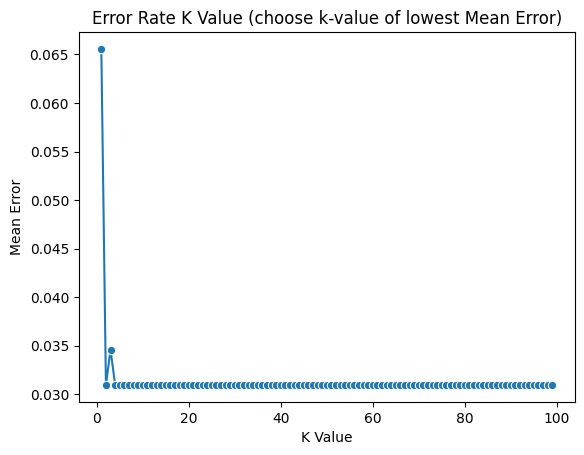

In [25]:
# CLASSIFIER VERSION
# adjust this to 50 or even 150 if you have lots of data rows
max_iterations = 100

# list to save the error values in the loop
error = []

# the default metric in scikit-learn
metric_selection = "minkowski"

# Calculating error for K values between 1 and 40
for i in range(1, max_iterations):

     # try with current k-value, train the model and make a test prediction
    knn = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=i, metric=metric_selection))
    knn.fit(X_train, y_train)
    pred_i = knn.predict(X_test)

    # save the error value for this k-value
    error.append(np.mean(pred_i != y_test))
    
# plot all the k-values and their error values
sns.lineplot(x=range(1, max_iterations), y=error, marker='o')
plt.title('Error Rate K Value (choose k-value of lowest Mean Error)')
plt.xlabel('K Value')
plt.ylabel('Mean Error')

# choose best k-value based on metrics
# we have to add +1 to k-value, since argmin() returns an index
# which starts from 0, but k-values start from 1
print("Based on iterations, best k-value is this:")
k_value = np.argmin(error) + 1
print(k_value)

In [26]:

# create the model and train it with the data
# model = LogisticRegression()
# use probability=True for easier metrics

# if you wish to use LinearSVC => we need to wrap it into a
# CalibratedClassifierCV so it outputs probabilities for the metrics
# model = make_pipeline(StandardScaler(), CalibratedClassifierCV(svm.LinearSVC()))

# Pipeline is super helpful here, since we can integrate the scaler
# before the model, no need to manually scale anything
model = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=k_value, metric=metric_selection))
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('standardscaler', ...), ('kneighborsclassifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",np.int64(2)
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depend

In [27]:
# we need to create test predictions based on our earlier reserved test dataset
# this data has never been seen by the model by now
predictions = model.predict(X_test)

<div style="border: 4px solid #4d87ddff; padding: 10px 12px; background: #1f2933; margin: 10px 0; text-align: left; border-radius: 10px; max-width: 100%; box-sizing: border-box; word-wrap: break-word;">
  <h2 style="color: #f9fafb; margin: 0 0 8px 0; font-size: 2em; letter-spacing: 3px;">
    OBSERVATIONS:
  </h2>

  <ul style="margin: 0 0 12px 18px; padding:0; color:#e5e7eb; font-size:16px; line-height:1.6;">
    <li>Model trains without crashing so that's a nice and it means the column are converted properly </li>
 
  </ul>
</div>

---

<div style="background-color:#1f2933; padding:14px 18px; border-radius:10px; border-left:5px solid #4d87ddff; width: fit-content;">

<h3 style="margin:0; color:#f9fafb;">
<b> STEP 5: Error and performance metrics</b>
</h3>
</div>


<h3 style='color:orange'>
  <b>Classification error metrics
</b>
</h3>

In [28]:
# we need to create test predictions based on our earlier reserved test dataset
# this data has never been seen by the model by now
predictions = model.predict(X_test)

In [29]:
# printing the classification report based on true values and predictions
print(classification_report(y_test, predictions))

# getting overall accuracy of the model and printing it
acc = accuracy_score(y_test, predictions)
print("\nModel overall accuracy: {:.2f}%".format(acc * 100))

              precision    recall  f1-score   support

           0       0.97      1.00      0.98       532
           1       0.00      0.00      0.00        17

    accuracy                           0.97       549
   macro avg       0.48      0.50      0.49       549
weighted avg       0.94      0.97      0.95       549


Model overall accuracy: 96.90%


/Users/SaadMahmood/Introduction-to-Machine-Learning-Methods/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/SaadMahmood/Introduction-to-Machine-Learning-Methods/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/SaadMahmood/Introduction-to-Machine-Learning-Methods/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `

<div style="border: 4px solid #4d87ddff; padding: 10px 12px; background: #1f2933; margin: 10px 0; text-align: left; border-radius: 10px; max-width: 100%; box-sizing: border-box; word-wrap: break-word;">  <h2 style="color: #f9fafb; margin: 0 0 8px 0; font-size: 2em; letter-spacing: 3px;">
    OBSERVATIONS:
  </h2>

  <ul style="margin: 0 0 12px 18px; padding:0; color:#e5e7eb; font-size:16px; line-height:1.6;">
    <li>Model overall accuracy: 96.90% </li>
  
 
  </ul>
</div>



<Axes: >

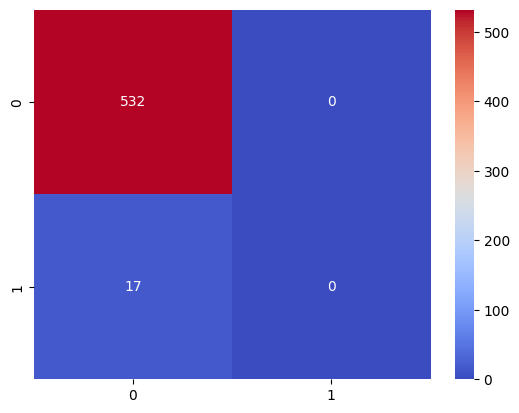

In [30]:
# see the confusion matrix
sns.heatmap(confusion_matrix(y_test, predictions), annot=True, fmt='g', cmap='coolwarm')


In [31]:
# The AUC score is a super sensitive metric
# you often get low scores, even 0.5

# in binary logistic regression, AUC values are often interpreted as follows:
# A binary classifier is useful only when it achieves ROC-AUC score greater than 0.5 and as near to 1 as possible. 
# If a classifier yields a score less than 0.5, it simply means that the model is performing worse 
# than a random classifier, and therefore is useless.

# In multinomial logistic regression , AUC values are often interpreted as follows: 
# 0.5-0.6 (failed)
# 0.6-0.7 (worthless)
# 0.7-0.8 (poor)
# 0.8-0.9 (good)
# > 0.9 (excellent)

# basically 0.5 means you could get the same result with just random guessing
roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])

0.49933657673595755

<div style="border: 4px solid #4d87ddff; padding: 10px 12px; background: #1f2933; margin: 10px 0; text-align: left; border-radius: 10px; max-width: 100%; box-sizing: border-box; word-wrap: break-word;">
  <h2 style="color: #f9fafb; margin: 0 0 8px 0; font-size: 2em; letter-spacing: 3px;">
    OBSERVATIONS:
  </h2>
  <ul style="margin: 0 0 12px 18px; padding:0; color:#e5e7eb; font-size:16px; line-height:1.6;">
    <li>The ROC AUC score is <b>0.499</b>, which falls in the <b>failed</b> range (below 0.5). 
    This means the model is performing no better than random guessing.</li>
    <li>The confusion matrix confirms this: the model predicted <b>class 0 for almost every row</b>.</li>
  </ul>
</div>

<div style="border: 4px solid #4d87ddff; padding: 10px 12px; background: #1f2933; margin: 10px 0; text-align: left; border-radius: 10px;">
  <h2 style="color: #f9fafb; margin: 0 0 8px 0; font-size: 2em; letter-spacing: 3px;">
    OBSERVATIONS:
  </h2>

  <ul style="margin: 0 0 12px 18px; padding:0; color:#e5e7eb; font-size:16px; line-height:1.6;">
    <li>The ROC AUC score is <b>0.499</b>, which falls in the <b>failed</b> range (below 0.5). 
    This means the model is performing no better than random guessing.</li>
    <li>The confusion matrix confirms this: the model predicted <b>class 0 for almost every row</b>.</li>
  </ul>
</div>

---


<div style="background-color:#1f2933; padding:14px 18px; border-radius:10px; border-left:5px solid  #4d87ddff; width: fit-content;">

<h3 style="margin:0; color:#f9fafb;">
<b> Using the model in practice</b>
</h3>
</div>


In [32]:
df.columns.tolist()

['Transaction_Date',
 'Customer_Age',
 'Customer_Loyalty_Tier',
 'Purchase_Amount',
 'Fraud_Flag',
 'Footfall_Count',
 'Product_Category_Blush',
 'Product_Category_Concealer',
 'Product_Category_Eyeliner',
 'Product_Category_Eyeshadow Palette',
 'Product_Category_Foundation',
 'Product_Category_Highlighter',
 'Product_Category_Lipstick',
 'Product_Category_Mascara',
 'Product_Category_Serum',
 'Product_Category_Setting Spray',
 'Payment_Method_Credit Card',
 'Payment_Method_Debit Card',
 'Payment_Method_Gift Card',
 'Payment_Method_Mobile Payment',
 'Device_Type_Desktop',
 'Device_Type_Laptop',
 'Device_Type_Mobile',
 'Device_Type_Tablet',
 'Location_Cannes',
 'Location_Dubai',
 'Location_Geneva',
 'Location_Hong Kong',
 'Location_Las Vegas',
 'Location_London',
 'Location_Los Angeles',
 'Location_Miami',
 'Location_Milan',
 'Location_Monaco',
 'Location_Monte Carlo',
 'Location_New York',
 'Location_Paris',
 'Location_Rome',
 'Location_San Francisco',
 'Location_Shanghai',
 'Location_

<h3 style='color:orange'>
  <b> I did not create a new input row for this model because the dataset is synthetic and the values would not be meaningful.
</b>
</h3>

---

<div style="border: 4px solid #4d87ddff; padding: 10px 12px; background: #1f2933; margin: 10px 0; text-align: left; border-radius: 10px; max-width: 100%; box-sizing: border-box; word-wrap: break-word;">
  <h2 style="color: #f9fafb; margin: 0 0 8px 0; font-size: 2em; letter-spacing: 3px;">
    CONCLUSION:
  </h2>
  <ul style="margin: 0 0 12px 18px; padding:0; color:#e5e7eb; font-size:16px; line-height:1.6;">
    <li>When we started building this ML model, the dataset was in rough shape. We went through detailed preprocessing: removing irrelevant columns, transforming values, and more. After filtering, we were left with <strong style="color:#4d87ddff;">1830 rows and 12 columns</strong>, most of which were nominal and required encoding before training.</li>
    <br>
    <li>I dropped <strong style="color:#4d87ddff;">IP_Address, Transaction_Time, Customer_ID,</strong> and <strong style="color:#4d87ddff;">Transaction_ID</strong> because they are identifiers that do not help with prediction and can cause problems during model training.</li>
    <br>
    <li>There were some <strong style="color:#4d87ddff;">null values</strong> present which were removed to ensure clean data. The column <strong style="color:#4d87ddff;">Purchase_Amount</strong> has the highest number of unique values and was already numeric, so no transformation was needed. The same applies to <strong style="color:#4d87ddff;">Fraud_Flag</strong> and <strong style="color:#4d87ddff;">Footfall_Count</strong>.</li>
    <br>
    <li>There is <strong style="color:#4d87ddff;">1 binary column</strong> which is also the target variable and required no encoding. Columns such as <strong style="color:#4d87ddff;">Product_Category, Payment_Method, Device_Type, Location, Store_ID,</strong> and <strong style="color:#4d87ddff;">Product_SKU</strong> were treated as nominal and encoded accordingly.</li>
    <br>
    <li>Training went completely smoothly without any crashes, which confirmed that all column conversions were done correctly.</li>
    <br>
    <li>The model achieved an overall accuracy of <strong style="color:#4d87ddff;">96.90%</strong>. However, the ROC AUC score of <strong style="color:#4d87ddff;">0.499</strong> and the confusion matrix showing class 0 predicted for almost every row strongly suggest that this is a <strong style="color:#4d87ddff;">synthetic dataset</strong> with no real patterns for the model to learn from.</li>
  </ul>
</div>

---

<div style="background-color:#1f2933; padding:14px 18px; border-radius:10px; border-left:5px solid  #4d87ddff; width: fit-content;">

<h3 style="margin:0; color:#f9fafb;">
<b> AI Usage</b>
</h3>
</div>


<h3>
<strong style='color:orange ;'>Yes (for html and style)
 </strong>
</h3>




---


<div style="background-color:#1f2933; padding:14px 18px; border-radius:10px; border-left:5px solid #4d87ddff; width: fit-content;">

<h1 style="margin:0; color:#f9fafb;">
<b>Ideas for further improvements:</b>
</h1>
</div>


<h5 style='color:orange'>
  <b>Have Different Dataset</b>
</h5>